In [14]:
import os
import sys
import math
import torch
import random
import numpy as np
import torch.nn as nn
from pathlib import Path
import torch.nn.functional as F
import matplotlib.pyplot as plt
from einops import rearrange, reduce, repeat, einsum

import training_runtime 
import inference_runtime


In [11]:
MODEL_CONFIGS = {
    "embed_dim"   : 2**5,   # 32
    "max_seq_len" : 2**6,   # 64
    "batch_size"  : 2**4,   # 16
    "vocab_size"  : 2**11,  # 2048
    "learning_rate" : 1e-3,
    "save_path" : "../models/level1_bigram_weights.pt",
    "loss_history" : "../models/level1_loss_history.txt",
}

In [3]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)

cuda


In [4]:
# define model arch

class Level1BigramLM(nn.Module):
    def __init__(self):
        super().__init__()

        self.vocab_size = MODEL_CONFIGS["vocab_size"]
        self.embed_dim = MODEL_CONFIGS["embed_dim"]
        
        self.embed = nn.Parameter(torch.randn(self.vocab_size, self.embed_dim) * 0.02)
        self.unembed = nn.Parameter(torch.randn(self.embed_dim, self.vocab_size) * 0.02)



    def forward(self, idx: torch.Tensor)-> torch.Tensor:

        batch_size, seq_len = idx.shape 

        # 1. Embedding Lookup: Retrieve vector representations
        x = self.embed[idx]

        # 2. Unembedding Projection: Project directly to vocabulary
        logits = einsum(x, self.unembed, 
                        "batch_size seq_len embed_dim, embed_dim vocab_size"
                        " -> "
                        "batch_size seq_len vocab_size")

        return logits


Step 0000 | Batch Loss: 7.6246 nats
Step 0005 | Batch Loss: 7.6245 nats
Step 0010 | Batch Loss: 7.6242 nats
Step 0015 | Batch Loss: 7.6238 nats
Step 0020 | Batch Loss: 7.6236 nats
Step 0025 | Batch Loss: 7.6232 nats
Step 0030 | Batch Loss: 7.6226 nats
Step 0035 | Batch Loss: 7.6216 nats
Step 0040 | Batch Loss: 7.6214 nats
Step 0045 | Batch Loss: 7.6208 nats
Step 0050 | Batch Loss: 7.6199 nats
Step 0055 | Batch Loss: 7.6182 nats
Step 0060 | Batch Loss: 7.6172 nats
Step 0065 | Batch Loss: 7.6148 nats
Step 0070 | Batch Loss: 7.6128 nats
Step 0075 | Batch Loss: 7.6121 nats
Step 0080 | Batch Loss: 7.6071 nats
Step 0085 | Batch Loss: 7.6042 nats
Step 0090 | Batch Loss: 7.6010 nats
Step 0095 | Batch Loss: 7.5919 nats
Step 0099 | Batch Loss: 7.5897 nats

Saving model weights to: ../models/level1_bigram_weights.pt
Loss history successfully saved to ../models/level1_loss_history.txt
Loaded 100 steps from ../models/level1_loss_history.txt


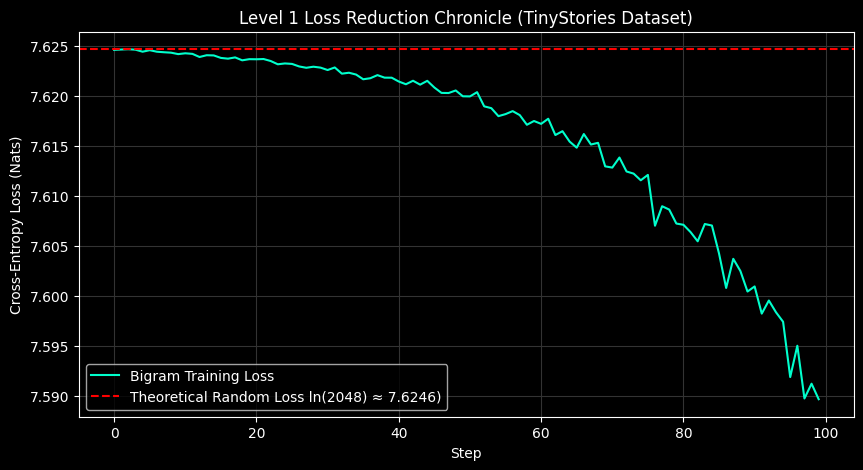

In [ ]:

model = Level1BigramLM()
configs = MODEL_CONFIGS

# trains and plots loss curves

training_runtime.train_and_save_model(model, configs, device, 100)
training_runtime.plot_loss_history(configs)


In [ ]:
# inference

model_scaffold = Level1BigramLM()


